In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import yaml
import torch
import numpy as np
from box import Box
from pathlib import Path
from utils import plotPCbatch
from wgan_utils import generate_sample
from dataloaders import GetDataLoaders
from models import PointCloudAE, Generator

In [ ]:
with open("config.yaml", "r") as file:
    args = yaml.safe_load(file)
args = Box(args)
print(args)

args.data_dir = Path.home()/args.data_dir
args.model_dir = Path.home()/args.model_dir

{'device': 'cuda', 'batch_size': 32, 'data_dir': 'onedrive_local/research/material_liu/data', 'model_dir': 'onedrive_local/research/material_liu/model', 'load_ae': False, 'dataset': 'chair_set.npy', 'output_folder': 'output/', 'save_results': True, 'latent_size': 128, 'ae_epoch': 1001, 'gan_epoch': 100, 'gan_batch': 64, 'lambda_gp': 10}


In [ ]:
data_file = args.data_dir/args.dataset
pc_array = np.load(data_file)
print(f"data shape: {pc_array.shape}.")

point_size = pc_array.shape[1]
print(f"number of points in one 3D cloud: {point_size}.")
loader, _ = GetDataLoaders(npArray=pc_array, 
                           batch_size=args.batch_size, 
                           train_set_percentage=1.0)

data shape: (3746, 1024, 3).
number of points in one 3D cloud: 1024.


Successfully load ae!
Successfully load wgan generator!


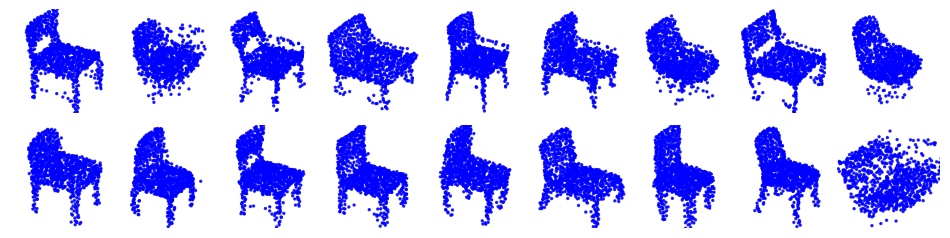

In [ ]:
if __name__ == "__main__":
    
    # load saved ae
    ae = PointCloudAE(point_size, args.latent_size).to(args.device)
    checkpoint = torch.load(args.model_dir/"ae.pt", weights_only=True)
    ae.load_state_dict(checkpoint)
    ae.eval()
    print("Successfully load ae!")

    # load saved generator
    generator = Generator().to(args.device)
    checkpoint = torch.load(args.model_dir/"wgan_g.pt", weights_only=True)
    generator.load_state_dict(checkpoint)
    generator.eval()
    print("Successfully load wgan generator!")

    #display generated samples
    sample1 = generate_sample(generator, ae, args.batch_size, args.device, latent_dim=128)
    sample2 = generate_sample(generator, ae, args.batch_size, args.device, latent_dim=128)
    plotPCbatch(sample1, sample2)